### Calculate the statistical information for all constituent stocks and examine their normality.

In [ ]:
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def calculate_industry_statistics():
    trading_data1 = pd.read_csv('TRD_Dalyr(20150105-20200103).csv')
    trading_data1['Trddt'] = pd.to_datetime(trading_data1['Trddt'])
    trading_data1_2020 = trading_data1[trading_data1['Trddt'] >= '2020-01-01']
    trading_data2 = pd.read_csv('TRD_Dalyr(20200106-20241213).csv')
    trading_data2['Trddt'] = pd.to_datetime(trading_data2['Trddt'])
    trading_data = pd.concat([trading_data1_2020, trading_data2], ignore_index=True)

    industry_data = pd.read_excel('行业分类.xlsx')

    listing_data = pd.read_excel('FI(季频).xlsx')

    listing_data.columns = listing_data.columns.str.strip()
    listing_data['code'] = listing_data['code'].astype(str).str.zfill(6)
    listing_data['listingDate'] = pd.to_datetime(listing_data['listingDate'])
    listing_data['listing_year'] = listing_data['listingDate'].dt.year
    stocks_to_remove = listing_data[listing_data['listing_year'] > 2014]['code'].tolist()

    trading_data.columns = trading_data.columns.str.strip()
    industry_data.columns = industry_data.columns.str.strip()
    trading_data['Stkcd'] = trading_data['Stkcd'].astype(str).str.zfill(6)
    industry_data['股票代码'] = industry_data['股票代码'].astype(str).str.zfill(6)

    merged_data = pd.merge(
        trading_data,
        industry_data,
        left_on='Stkcd',
        right_on='股票代码',
        how='inner'
    )

    merged_data = merged_data[~merged_data['Stkcd'].isin(stocks_to_remove)]

    remaining_stocks = merged_data['Stkcd'].nunique()
    print(f"删除后剩余股票数量: {remaining_stocks} 只")

    if 'Trddt' not in merged_data.columns or merged_data['Trddt'].dtype != 'datetime64[ns]':
        merged_data['Trddt'] = pd.to_datetime(merged_data['Trddt'])
    merged_data = merged_data[
        (merged_data['Trddt'] >= '2020-01-01') & 
        (merged_data['Trddt'] <= '2024-12-31')
    ]

    merged_data['ChangeRatio'] = pd.to_numeric(merged_data['ChangeRatio'], errors='coerce')
    merged_data = merged_data.dropna(subset=['ChangeRatio'])
    stock_stats_list = []
    
    for stock_code, stock_data in merged_data.groupby('Stkcd'): 
        returns = stock_data['ChangeRatio']
        industry = stock_data['行业'].iloc[0]
        
        # 计算该股票的统计量
        stock_mean = returns.mean() * 100  # 转换为百分比
        stock_std = returns.std() 
        stock_skew = stats.skew(returns)
        stock_kurt = stats.kurtosis(returns)
        stock_jb, stock_jb_pvalue = stats.jarque_bera(returns)
        
        stock_stats_list.append({
            'Stkcd': stock_code,
            'Industry': industry,
            'ObsCount': len(returns),
            'Mean': stock_mean,
            'Std': stock_std,
            'Skew': stock_skew,
            'Kurt': stock_kurt,
            'JB': stock_jb,
            'JB_pvalue': stock_jb_pvalue
        })

    stock_stats_df = pd.DataFrame(stock_stats_list)
    
    industry_stats = []
    
    for industry in stock_stats_df['Industry'].unique():
        industry_stocks = stock_stats_df[stock_stats_df['Industry'] == industry]
        
        # 计算行业统计量（个股统计量的平均）
        industry_stat = {
            'Industry': industry,
            'Number': len(industry_stocks),
            'Mean(%)': round(industry_stocks['Mean'].mean(), 4),
            'SD': round(industry_stocks['Std'].mean(), 4),
            'Skew': round(industry_stocks['Skew'].mean(), 4),
            'Kurt': round(industry_stocks['Kurt'].mean(), 4),
            'JB_test': round(industry_stocks['JB'].mean(), 4),
            'p-value': round(industry_stocks['JB_pvalue'].mean(), 4)
        }
        
        industry_stats.append(industry_stat)

    stats_df = pd.DataFrame(industry_stats)
    stats_df = stats_df.sort_values('Number', ascending=False).reset_index(drop=True)
    
    # 计算全市场统计量（所有个股统计量的平均）
    total_stats = {
        'Industry': 'All',
        'Number': len(stock_stats_df),
        'Mean(%)': round(stock_stats_df['Mean'].mean(), 4),
        'SD': round(stock_stats_df['Std'].mean(), 4),
        'Skew': round(stock_stats_df['Skew'].mean(), 4),
        'Kurt': round(stock_stats_df['Kurt'].mean(), 4),
        'JB_test': round(stock_stats_df['JB'].mean(), 4),
        'p-value': round(stock_stats_df['JB_pvalue'].mean(), 4)
    }
    stats_df = pd.concat([stats_df, pd.DataFrame([total_stats])], ignore_index=True) 
    return stats_df, merged_data, stock_stats_df

def display_results_table(stats_df):
    if stats_df is None:
        return None
    
    print("\n" + "="*100) 
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    formatted_df = stats_df.copy()

    for col in ['Mean(%)', 'SD', 'Skew', 'Kurt', 'JB_test','p-value']:
        formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:8.4f}")


    print(f"{'Industry':<20} {'Number':<8} {'Mean(%)':<10} {'SD':<10} {'Skew':<10} {'Kurt':<10} {'JB_test':<12} {'p-value':<12}")
    print("-" * 100)
    
    for _, row in formatted_df.iterrows():
        print(f"{row['Industry']:<20} {row['Number']:<8} {row['Mean(%)']:<10} {row['SD']:<10} {row['Skew']:<10} {row['Kurt']:<10} {row['JB_test']:<12} {row['p-value']:<12}")
    
    print("="*100)
    return stats_df

if __name__ == "__main__":
    result = calculate_industry_statistics()
    stats_df, merged_data, stock_stats_df = result
    result_df = display_results_table(stats_df)


删除后剩余股票数量: 141 只

Industry             Number   Mean(%)    SD         Skew       Kurt       JB_test      p-value     
----------------------------------------------------------------------------------------------------
Financials           31         0.0356     0.0175     0.6498     6.1920   2429.1339      0.0000    
Industrials          28         0.0513     0.0224     0.5049     3.8239   933.4256       0.0000    
Information Technology 16         0.0609     0.0277     0.4404     2.3404   420.0994       0.0000    
Materials            15         0.0661     0.0256     0.4413     2.4695   401.8602       0.0000    
Health Care          14         0.0310     0.0248     0.4693     3.8644   870.7950       0.0000    
Consumer Discretionary 11         0.0711     0.0247     0.4790     2.3477   397.9849       0.0000    
Consumer Staples     11         0.0424     0.0228     0.3594     2.8961   477.9916       0.0000    
Energy               6          0.0735     0.0211     0.3365     3.1323   545

### 计算2024年收益率

In [ ]:
import pandas as pd
def get_excluded_stocks():
    df_fi = pd.read_excel("FI(季频).xlsx")
    df_filtered = df_fi[df_fi['EndDate'] == '2014-12'].copy()
    df_filtered['listingYear'] = pd.to_datetime(df_filtered['listingDate']).dt.year
    condition = df_filtered['listingYear'] > 2014
    stocks_to_exclude = df_filtered[condition]['code'].tolist()
    print(f"需要剔除的股票数量: {len(stocks_to_exclude)}")
    return stocks_to_exclude

def calculate_2024_stock_returns():
    excluded_stocks = get_excluded_stocks()
    df_price = pd.read_csv("TRD_Dalyr(20200106-20241213).csv")
    df_price['Trddt'] = pd.to_datetime(df_price['Trddt'])
    df_price['year'] = df_price['Trddt'].dt.year
    print(f"剔除前股票数量: {df_price['Stkcd'].nunique()}")
    df_price = df_price[~df_price['Stkcd'].isin(excluded_stocks)]
    print(f"剔除后股票数量: {df_price['Stkcd'].nunique()}")

    df_price_filtered = df_price[df_price['year'].isin([2023, 2024])].copy()

    stock_returns = []
    processed_stocks = 0
    
    unique_stocks = df_price_filtered['Stkcd'].unique()
    print(f"计算 {len(unique_stocks)} 只股票的收益率")
    
    for i, stock in enumerate(unique_stocks):
        if (i + 1) % 20 == 0:
            print(f"已计算 {i + 1}/{len(unique_stocks)} 只股票")
            
        stock_data = df_price_filtered[df_price_filtered['Stkcd'] == stock].copy()
        stock_data = stock_data.sort_values('Trddt')
        
        # 获取2023年最后一个交易日的收盘价（期初价格）
        price_2023 = stock_data[stock_data['year'] == 2023]['Clsprc']
        start_price = price_2023.iloc[-1]
        start_date = stock_data[stock_data['year'] == 2023]['Trddt'].iloc[-1]
        
        # 获取2024年最后一个交易日的收盘价（期末价格）
        price_2024 = stock_data[stock_data['year'] == 2024]['Clsprc']
        end_price = price_2024.iloc[-1]
        end_date = stock_data[stock_data['year'] == 2024]['Trddt'].iloc[-1]
    
        # 计算收益率
        annual_return = (end_price - start_price) / start_price
        
        stock_returns.append({
            'stock_code': stock,
            'start_date': start_date.strftime('%Y-%m-%d'),
            'end_date': end_date.strftime('%Y-%m-%d'),
            'start_price_2023': round(start_price, 6),
            'end_price_2024': round(end_price, 6),
            'annual_return_2024': round(annual_return, 6),
            'annual_return_pct': round(annual_return * 100, 2)
        })
        processed_stocks += 1
    
    print(f"成功计算: {processed_stocks} 只股票")

    df_returns = pd.DataFrame(stock_returns)

    output_file = '股票2024年收益率.csv'
    df_returns.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"结果已保存到: {output_file}")

    return df_returns


def main():
    calculate_2024_stock_returns()

if __name__ == "__main__":
    main()

需要剔除的股票数量: 21
剔除前股票数量: 162
剔除后股票数量: 141
计算 141 只股票的收益率
已计算 20/141 只股票
已计算 40/141 只股票
已计算 60/141 只股票
已计算 80/141 只股票
已计算 100/141 只股票
已计算 120/141 只股票
已计算 140/141 只股票
成功计算: 141 只股票
结果已保存到: 股票2024年收益率.csv


### Display the scatterplot illustrating the relationship between FIs and stock returns (2024).

基本面数据处理完成，共162只股票
成功合并 141 只股票的数据
数据清理完成: 141 -> 99 样本


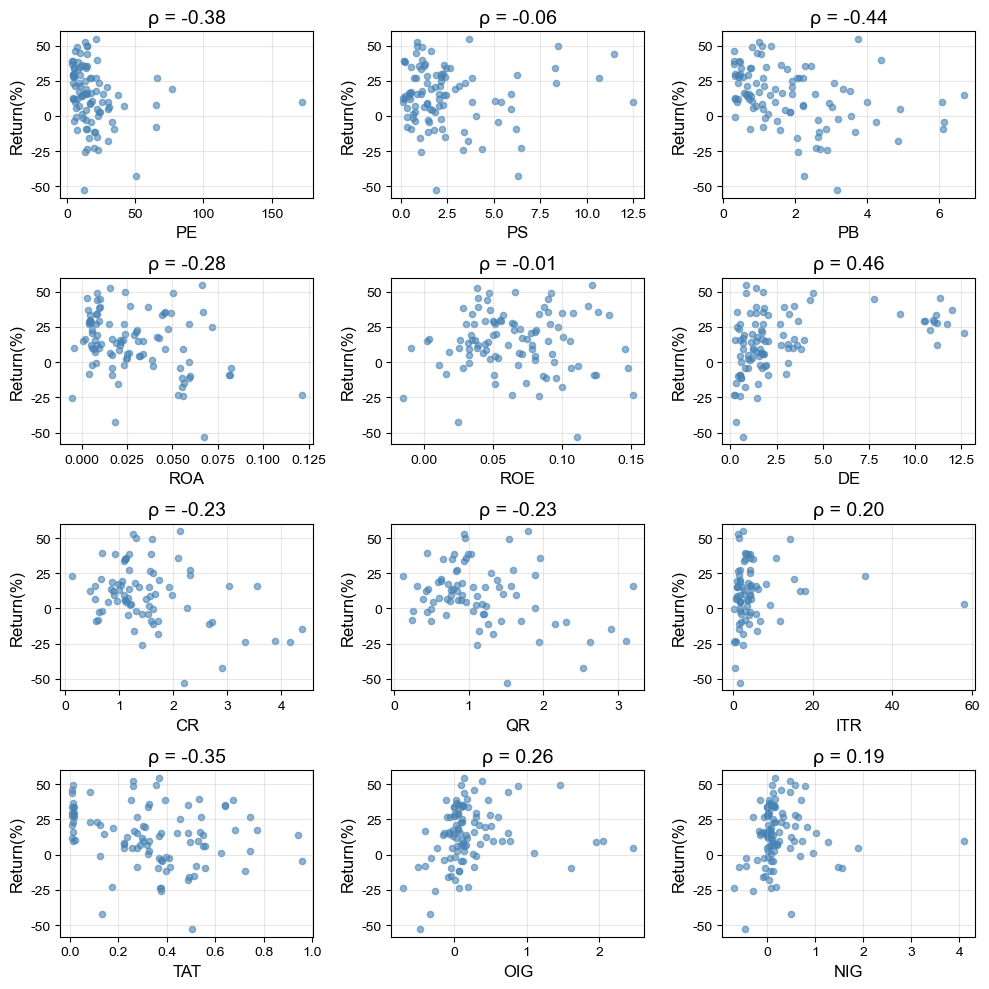

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

def load_and_process_fundamental_data():
    df_fi = pd.read_csv("fundamental_data_72_features_lagged.csv", encoding="utf-8-sig")
    fundamental_columns = ['PE', 'PS', 'PB', 'ROA', 'ROE', 'DE', 'CR', 'QR', 'ITR', 'TAT', 'OIG', 'NIG']
    df_fi['date'] = pd.to_datetime(df_fi['date'], errors='coerce')
    df_2024 = df_fi[df_fi['date'].dt.year == 2024].copy()   
    columns_to_use = ['stock_code', 'date'] + fundamental_columns
    df_selected = df_2024[columns_to_use].copy()

    for col in fundamental_columns:
        df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

    stock_indicator_validity = {}
    stock_codes = df_selected['stock_code'].unique()
    
    for stock_code in stock_codes:
        stock_data = df_selected[df_selected['stock_code'] == stock_code]
        stock_indicator_validity[str(stock_code)] = {}
        
        for indicator in fundamental_columns:
            indicator_series = stock_data[indicator].dropna()
            
            variance = indicator_series.var()
            if pd.isna(variance) or variance <= 1e-10:
                stock_indicator_validity[str(stock_code)][indicator] = False
            else:
                stock_indicator_validity[str(stock_code)][indicator] = True

    df_avg = df_selected.groupby('stock_code')[fundamental_columns].mean().reset_index()
    df_avg['stock_code'] = df_avg['stock_code'].astype(str)
    
    print(f"基本面数据处理完成，共{len(df_avg)}只股票")
    return df_avg, stock_indicator_validity


def load_return_data():
    df_return = pd.read_csv("股票2024年收益率.csv")
    df_return['stock_code'] = df_return['stock_code'].astype(str)
    return df_return[['stock_code', 'annual_return_pct']]

def merge_data(df_fundamental, df_return):
    df_fundamental['stock_code'] = df_fundamental['stock_code'].astype(str)
    df_return['stock_code'] = df_return['stock_code'].astype(str)
    df_merged = pd.merge(df_fundamental, df_return, on='stock_code', how='inner')
    print(f"成功合并 {len(df_merged)} 只股票的数据")
    return df_merged

def clean_data(df_merged, indicators):

    df_clean = df_merged.copy()
    original_count = len(df_clean)
    
    # 去除收益率的极端异常值（超过±200%的）
    df_clean = df_clean[(df_clean['annual_return_pct'] >= -200) & 
                       (df_clean['annual_return_pct'] <= 200)]
    
    # 去除基本面指标的极端异常值
    for indicator in indicators:
        if indicator in df_clean.columns:
            Q1 = df_clean[indicator].quantile(0.01)
            Q3 = df_clean[indicator].quantile(0.99)
            df_clean = df_clean[(df_clean[indicator] >= Q1) & (df_clean[indicator] <= Q3)]
    
    print(f"数据清理完成: {original_count} -> {len(df_clean)} 样本")
    return df_clean

def filter_valid_data_for_indicator(df_clean, indicator, stock_indicator_validity):
    valid_indices = []
    
    for idx, row in df_clean.iterrows():
        stock_code_str = str(row['stock_code'])
        
        if (stock_code_str in stock_indicator_validity and 
            indicator in stock_indicator_validity[stock_code_str] and
            stock_indicator_validity[stock_code_str][indicator]):
            valid_indices.append(idx)
    
    df_valid = df_clean.loc[valid_indices]
    indicator_data = df_valid[indicator]
    return_data = df_valid['annual_return_pct']
    return indicator_data, return_data

def plot_correlation_scatter(df_clean,stock_indicator_validity): 
    indicators = ['PE', 'PS', 'PB', 'ROA', 'ROE', 'DE', 'CR', 'QR', 'ITR', 'TAT', 'OIG', 'NIG']
    
    available_indicators = [ind for ind in indicators if ind in df_clean.columns]
    n_indicators = len(available_indicators)
    n_cols = 3
    n_rows = (n_indicators + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.5*n_rows))
    # 绘制每个指标的散点图
    for i, indicator in enumerate(available_indicators):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        # 为当前指标过滤有效数据
        x_data, y_data = filter_valid_data_for_indicator(df_clean, indicator, stock_indicator_validity)
        corr_coef = spearmanr(x_data, y_data)
        
        # 绘制散点图
        ax.scatter(x_data, y_data, alpha=0.6, s=20, color='steelblue')
        
        # 设置标签和标题
        ax.set_xlabel(indicator, fontsize=12)
        ax.set_ylabel('Return(%)', fontsize=12)
        ax.set_title(f'ρ = {corr_coef:.2f}', fontsize=14)
        
        # 设置网格
        ax.grid(True, alpha=0.3)

    for i in range(len(available_indicators), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()

    filename = f'2024年基本面收益率相关性散点图_600dpi.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

def main():

    df_fundamental, stock_indicator_validity = load_and_process_fundamental_data()
    df_return = load_return_data()
    df_merged = merge_data(df_fundamental, df_return)
    indicators = ['PE', 'PS', 'PB', 'ROA', 'ROE', 'DE', 'CR', 'QR', 'ITR', 'TAT', 'OIG', 'NIG']
    df_clean = clean_data(df_merged, indicators)
    plot_correlation_scatter(df_clean, stock_indicator_validity)

if __name__ == "__main__":
    main()

### Display a heatmap showing the relationship between FIs and TIs (averaged across all stocks).

包含的股票数量: 141
逐股票、逐特征对计算相关系数
已计算1/141 只股票
已计算21/141 只股票
已计算41/141 只股票
已计算61/141 只股票
已计算81/141 只股票
已计算101/141 只股票
已计算121/141 只股票
已计算141/141 只股票


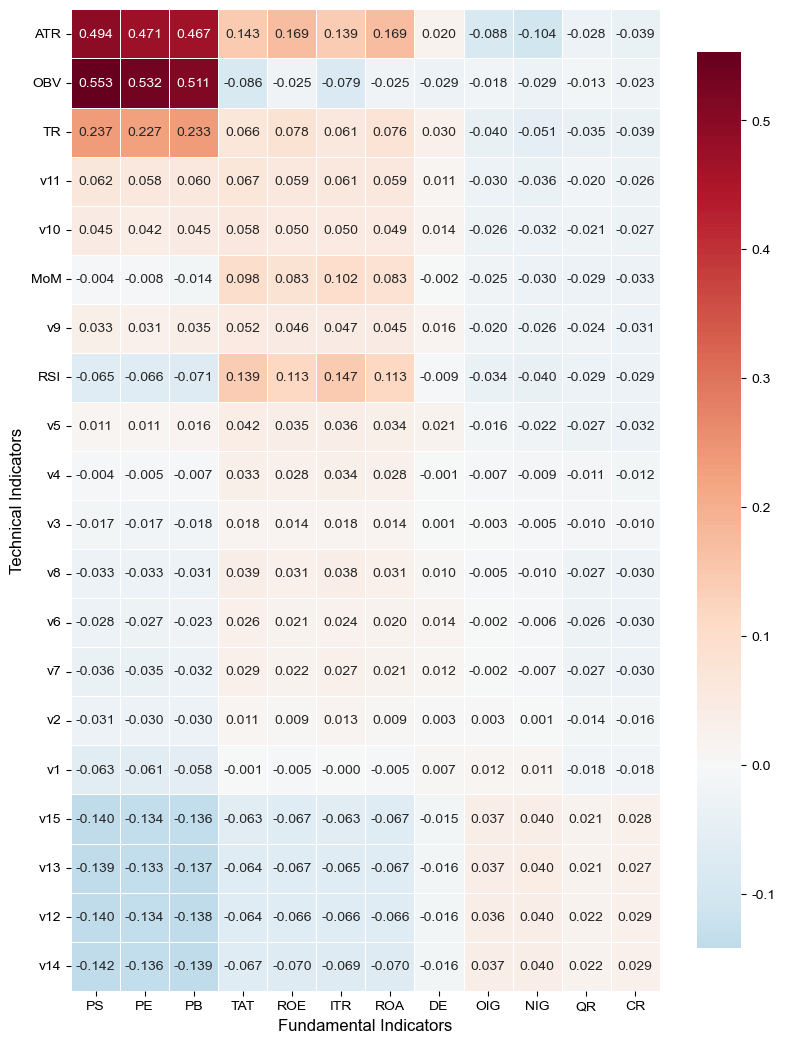

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

def load_and_filter_data():
    fundamental_df = pd.read_csv('FI汇总.csv')
    technical_df = pd.read_csv('TI汇总.csv')

    fundamental_df['date'] = pd.to_datetime(fundamental_df['date'])
    technical_df['date'] = pd.to_datetime(technical_df['date'])

    fundamental_2024 = fundamental_df[fundamental_df['date'].dt.year == 2024]
    technical_2024 = technical_df[technical_df['date'].dt.year == 2024]

    fundamental_selected = fundamental_2024[['stock_code', 'date'] + list(fundamental_2024.columns[2:14])]

    technical_selected = technical_2024[['stock_code', 'date'] + list(technical_2024.columns[2:])]

    fundamental_feature_cols = list(fundamental_2024.columns[2:14])
    technical_feature_cols = list(technical_2024.columns[2:])
    
    return fundamental_selected, technical_selected, fundamental_feature_cols, technical_feature_cols

def calculate_cross_correlation_by_stock(fundamental_data, technical_data, fundamental_cols, technical_cols):

    merged_data = pd.merge(fundamental_data, technical_data, on=['stock_code', 'date'], how='inner')
    print(f"包含的股票数量: {merged_data['stock_code'].nunique()}")

    stock_codes = merged_data['stock_code'].unique()

    n_fundamental = len(fundamental_cols)
    n_technical = len(technical_cols)
    
    correlation_sum = np.zeros((n_fundamental, n_technical))  # 相关系数总和
    count_matrix = np.zeros((n_fundamental, n_technical))     # 参与计算的股票数量
    
    print("逐股票、逐特征对计算相关系数")
    
    for stock_idx, stock_code in enumerate(stock_codes):
        if stock_idx % 20 == 0:
            print(f"已计算{stock_idx + 1}/{len(stock_codes)} 只股票")
        
        # 筛选当前股票的数据
        stock_data = merged_data[merged_data['stock_code'] == stock_code]
        
        # 对每个基本面-技术面特征对计算相关系数
        for i, fund_col in enumerate(fundamental_cols):
            for j, tech_col in enumerate(technical_cols):
                # 提取当前特征对的数据
                fund_series = stock_data[fund_col]
                tech_series = stock_data[tech_col]
                
                # 确保两个系列有相同的索引（日期对齐）
                common_idx = fund_series.index.intersection(tech_series.index)
                fund_aligned = fund_series.loc[common_idx]
                tech_aligned = tech_series.loc[common_idx]
                
                # 计算相关系数
                correlation = fund_aligned.corr(tech_aligned)
                
                # 检查相关系数是否有效
                if not np.isnan(correlation) and not np.isinf(correlation):
                    correlation_sum[i, j] += correlation
                    count_matrix[i, j] += 1
    average_correlation = np.divide(
        correlation_sum, 
        count_matrix, 
        out=np.zeros_like(correlation_sum), 
        where=(count_matrix != 0)
    )
    return average_correlation, count_matrix

def plot_correlation_heatmap(correlation_matrix, fundamental_cols, technical_cols, count_matrix=None):

    custom_cmap = cm.get_cmap("RdBu_r", 256)
    plt.subplots(figsize=(8.27, 11.69))

    transposed_matrix = correlation_matrix.T

    tech_avg = []
    for i in range(len(technical_cols)):
        row_values = transposed_matrix[i, :]
        if count_matrix is not None:
            valid_mask = count_matrix.T[i, :] > 0
            if valid_mask.any():
                tech_avg.append(np.mean(row_values[valid_mask]))
            else:
                tech_avg.append(0)

    fund_avg = []
    for j in range(len(fundamental_cols)):
        col_values = transposed_matrix[:, j]
        if count_matrix is not None:
            # 只考虑有效的相关系数
            valid_mask = count_matrix.T[:, j] > 0
            if valid_mask.any():
                fund_avg.append(np.mean(col_values[valid_mask]))
            else:
                fund_avg.append(0)

    tech_sort_indices = np.argsort(tech_avg)[::-1]  # 降序排列
    fund_sort_indices = np.argsort(fund_avg)[::-1]  # 降序排列

    sorted_matrix = transposed_matrix[np.ix_(tech_sort_indices, fund_sort_indices)]
    sorted_tech_cols = [technical_cols[i] for i in tech_sort_indices]
    sorted_fund_cols = [fundamental_cols[i] for i in fund_sort_indices]

    sns.heatmap(
        sorted_matrix,
        xticklabels=sorted_fund_cols,
        yticklabels=sorted_tech_cols, 
        cmap=custom_cmap,
        center=0,  # 以0为中心
        annot=True,  # 显示数值
        fmt='.3f',  
        square=True,  # 正方形单元格
        linewidths=0.5,  # 网格线宽度
        cbar_kws={"shrink": .8}
    )
    plt.xlabel('Fundamental Indicators', fontsize=12) 
    plt.ylabel('Technical Indicators', fontsize=12)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    filename = f'2024年热力图_600dpi.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

def main():
    fundamental_data, technical_data, fundamental_cols, technical_cols = load_and_filter_data()
    correlation_matrix, count_matrix = calculate_cross_correlation_by_stock(
        fundamental_data, technical_data, fundamental_cols, technical_cols
    )
    plot_correlation_heatmap(correlation_matrix, fundamental_cols, technical_cols, count_matrix)

if __name__ == "__main__":
    main()